In [ ]:
# THIS METHOD IS WRONG FOR IDENTIFYING ATOMS

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import tifffile
import os
from scipy.ndimage import gaussian_filter, binary_opening, label
from skimage import exposure, filters, morphology, measure
from scipy.signal import convolve2d
from skimage.morphology import disk
from skimage.feature import peak_local_max

from tqdm.notebook import tqdm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter Variable ss02']
plt.rcParams['figure.titlesize'] = 10
plt.rcParams['axes.titlesize'] = 10

In [3]:
os.listdir()

['bto02_objp_zstack_crop_08bit_iter1000.tif',
 'bto02_objp_zsum_crop_08bit_iter1000.tif',
 'bto05_objp_zstack_crop_08bit_iter1000.tif',
 'bto05_objp_zsum_crop_08bit_iter1000.tif',
 'bto08_objp_zstack_crop_08bit_iter0100.tif',
 'bto08_objp_zsum_crop_08bit_iter0100.tif',
 '260414.ipynb']

In [9]:
ptycho_stack = tifffile.imread('bto02_objp_zstack_crop_08bit_iter1000.tif') / 255
# ptycho_sum = tifffile.imread('bto02_objp_zsum_crop_08bit_iter1000.tif') / 255
ptycho_slice = ptycho_stack[13]
# bf = plt.imread('bf.png').mean(axis=2)
# bf = 1 - (bf - bf.min()) / (bf.max() - bf.min())
# haadf = plt.imread('haadf.png').mean(axis=2)
# haadf = (haadf - haadf.min()) / (haadf.max() - haadf.min()) 
# laadf = plt.imread('laadf.png').mean(axis=2)
# laadf = (laadf - laadf.min()) / (laadf.max() - laadf.min())

images = [ptycho_slice]
# names = ['Ptycho Sum', 'Ptycho Slice', 'Bright Field (Inverted)', 'HAADF', 'LAADF']

# fig, axs = plt.subplots(1, len(images), dpi=300)
# for i, ax in enumerate(axs):
#     ax.axis('off')
#     ax.imshow(images[i], cmap='gray')
#     ax.set_title(names[i], size=8)

# plt.tight_layout()

In [10]:
def feature_count_vs_radius(img, radii, high_pass=5):
    if high_pass:
        img = img - gaussian_filter(img, sigma=high_pass)

    counts = []
    peak_locs = []

    for r in tqdm(radii):
        # ---- 1. Build a disc kernel ------------------------------------
        # (skimage.disk returns a binary mask; we normalize it to sum = 1)
        kernel = disk(r).astype(float)
        kernel /= kernel.sum()

        # ---- 2. Convolve -------------------------------------------------
        conv = convolve2d(img, kernel, mode='same', boundary='symm')

        # ---- 3. Find local maxima ---------------------------------------
        #  * min_distance ensures that peaks are at least r pixels apart
        #  * threshold_abs picks peaks that stand out above the background
        peaks = peak_local_max(conv,
                            min_distance=int(r),
                            threshold_abs=conv.mean() + 2*conv.std(),
                            num_peaks=np.inf)

        counts.append(len(peaks))
        peak_locs.append(peaks)
        
    return radii, counts, peak_locs

In [11]:
r, c, pl = [], [], []
radii = np.arange(1, 32+1, 1)

for img in images:
    r_i, c_i, pl_i = feature_count_vs_radius(img, radii, high_pass=8)
    r.append(r_i)
    c.append(c_i)
    pl.append(pl_i)

  0%|          | 0/32 [00:00<?, ?it/s]

In [12]:
# fig, axs = plt.subplots(1, len(images), figsize=(18, 4), sharey=True, dpi=300)
# for i, ax in enumerate(axs):
#     ax.plot(r[i], c[i], 'ko-')
#     ax.set_xlim(r[i][0], r[i][-1])
#     ax.set_title(names[i])
#     ax.set_xlabel('Kernel radius (pixels)')
# axs[0].set_ylabel('Feature count')
# plt.tight_layout()

In [13]:
# idxs = [6, 14, 20]

# for i in range(len(images)):
#     plt.figure(dpi=300)
#     plt.imshow(images[i], cmap='gray')
#     for idx in idxs:
#         plt.scatter(
#             pl[i][idx][:,1],
#             pl[i][idx][:,0],
#             s=3,
#             edgecolors='none')
#     plt.axis('off')

#     plt.legend(['Ba', 'O', 'Ti'], loc='lower right')

#     plt.show()
#     plt.close()

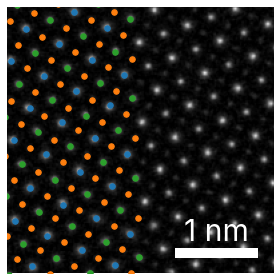

In [15]:
idxs = [6, 14, 20]
i = 0

plt.figure(dpi=72)
plt.imshow(images[i], cmap='gray')
for idx in idxs:
    plt.scatter(
        pl[i][idx][:,1][pl[i][idx][:,1] < 300],
        pl[i][idx][:,0][pl[i][idx][:,1] < 300],
        s=30,)
plt.axis('off')

plt.xlim(200, 400)
plt.ylim(200, 400)

# plt.legend(['Ba', 'O', 'Ti'], loc='lower right')

x = 385
L = 55
plt.plot([x - L, x], [215] *2, 'w-', lw=10)
plt.text(x - L/2, 220, '1 nm', color='w', ha='center', va='bottom', fontsize=30)

plt.show()
plt.close()